# **Step 1 : Identifying the Business Problem:**

  ## Predict the **total number of bike rentals** (cnt) on a given day
  ## based on weather, seasonal, and time-related features using Regression.

# Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Step 2 : Load the Dataset and Identify Basic Checks (Descriptive Analysis)**

In [2]:
df = pd.read_csv("day_2_.csv")

In [3]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,0.994472,2011-01-01,0.995843,0.016018,0.982600,-0.003477,5.992394,-0.001417,2.009839,0.350509,0.367939,0.787116,0.168656,330.998105,653.993691,985.007777
1,2.011503,2011-01-02,0.992476,0.000674,1.004417,0.002312,-0.002698,0.014306,1.988153,0.352450,0.364911,0.696719,0.259395,131.005296,669.996919,801.009116
2,2.992261,2011-01-03,1.012450,0.005877,0.981187,-0.015208,0.993581,0.991965,0.988943,0.179866,0.179076,0.442457,0.235277,119.995937,1229.016646,1349.003713
3,3.981679,2011-01-04,1.005005,-0.002214,1.032288,-0.002648,1.992651,0.998199,1.006277,0.194044,0.206866,0.614092,0.177329,108.020172,1453.995958,1562.008678
4,4.996911,2011-01-05,0.998953,0.017170,1.004892,-0.002176,3.003945,0.983012,0.992739,0.237016,0.208624,0.423478,0.184433,81.996052,1517.999923,1599.975184


In [4]:
df.shape

(46290, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46290 entries, 0 to 46289
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     46290 non-null  float64
 1   dteday      46290 non-null  object 
 2   season      46290 non-null  float64
 3   yr          46290 non-null  float64
 4   mnth        46290 non-null  float64
 5   holiday     46290 non-null  float64
 6   weekday     46290 non-null  float64
 7   workingday  46290 non-null  float64
 8   weathersit  46290 non-null  float64
 9   temp        46290 non-null  float64
 10  atemp       46290 non-null  float64
 11  hum         46290 non-null  float64
 12  windspeed   46290 non-null  float64
 13  casual      46290 non-null  float64
 14  registered  46290 non-null  float64
 15  cnt         46290 non-null  float64
dtypes: float64(15), object(1)
memory usage: 5.7+ MB


In [6]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,46290.000000,46290.000000,46290.000000,46290.000000,46290.000000,46290.000000,46290.000000,46290.000000,46290.000000,46290.000000,46290.000000,46290.000000,46290.000000,46290.000000,46290.000000
mean,364.735362,2.493732,0.498055,6.509260,0.028644,2.997321,0.684066,1.395294,0.495344,0.474318,0.627772,0.190528,847.438201,3650.648945,4498.087158
std,211.276393,1.109381,0.500004,3.447825,0.167323,2.003412,0.465009,0.544464,0.183330,0.163378,0.142664,0.078096,685.696084,1559.124480,1935.829352
min,0.975109,0.965999,-0.040280,0.958008,-0.041763,-0.037262,-0.037812,0.955438,0.038138,0.052926,-0.021972,-0.000746,1.977277,19.970274,21.970257
25%,181.011212,1.975404,0.000004,3.979010,-0.006597,1.006214,0.008069,0.997436,0.336478,0.336542,0.520505,0.134683,314.999931,2487.009402,3140.986483
50%,364.002251,2.029500,0.026959,6.980716,0.000330,3.000232,0.993868,1.008147,0.498046,0.485622,0.627524,0.180722,712.991623,3657.998088,4541.003332
75%,547.998136,3.018682,0.999790,9.974245,0.007416,4.993718,1.003402,1.996034,0.656292,0.610317,0.730046,0.234570,1095.016923,4762.994239,5935.997748
max,731.032441,4.040936,1.044274,12.033336,1.035419,6.034260,1.040272,3.031796,0.888560,0.868918,0.998568,0.526197,3410.023849,6946.022853,8714.020939


In [7]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [8]:
df.isnull().sum()/len(df)*100

instant       0.0
dteday        0.0
season        0.0
yr            0.0
mnth          0.0
holiday       0.0
weekday       0.0
workingday    0.0
weathersit    0.0
temp          0.0
atemp         0.0
hum           0.0
windspeed     0.0
casual        0.0
registered    0.0
cnt           0.0
dtype: float64

# **Step 3 : Exploratory Data Analysis**

# **1. UNIVARIATE ANALYSIS (Single Variable)**

## **A) Numerical Columns**

### **Histogram**

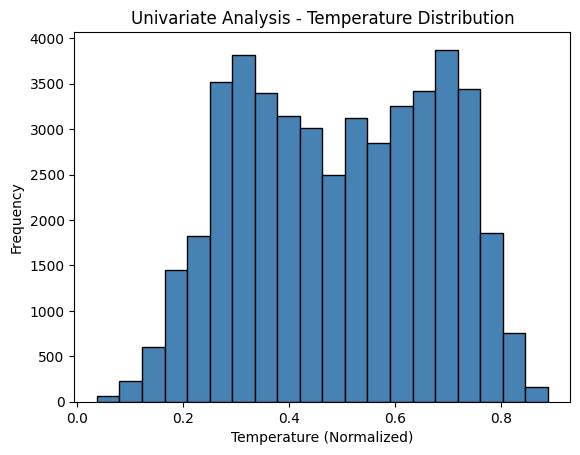

In [9]:
# Numerical Univariate - Temperature
plt.figure()
plt.hist(df['temp'], bins=20, color='steelblue', edgecolor='black')
plt.title('Univariate Analysis - Temperature Distribution')
plt.xlabel('Temperature (Normalized)')
plt.ylabel('Frequency')
plt.show()

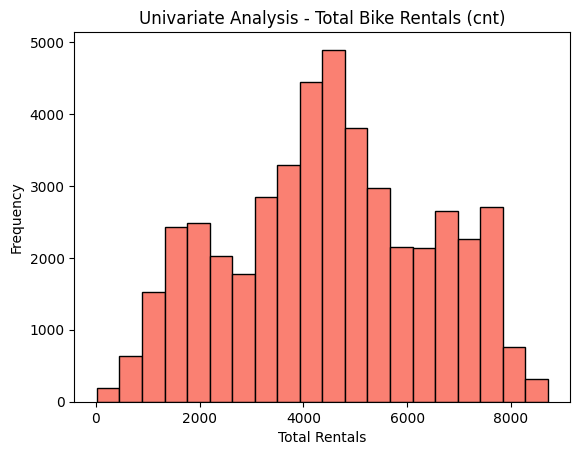

In [10]:
# Numerical Univariate - cnt (Target Variable)
plt.figure()
plt.hist(df['cnt'], bins=20, color='salmon', edgecolor='black')
plt.title('Univariate Analysis - Total Bike Rentals (cnt)')
plt.xlabel('Total Rentals')
plt.ylabel('Frequency')
plt.show()

# **2. BIVARIATE ANALYSIS (Two Variables)**

## **A) Numerical vs Numerical**

### **Scatter Plot**

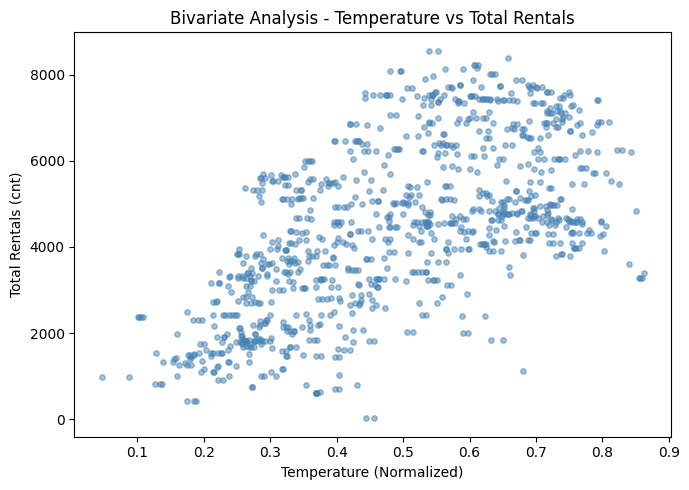

In [11]:
# Sample for faster plotting
df_plot = df.sample(n=min(1000, len(df)), random_state=42)
plt.figure(figsize=(7, 5))
plt.scatter(df_plot['temp'], df_plot['cnt'], alpha=0.5, color='steelblue', s=15)
plt.title('Bivariate Analysis - Temperature vs Total Rentals')
plt.xlabel('Temperature (Normalized)')
plt.ylabel('Total Rentals (cnt)')
plt.tight_layout()
plt.show()

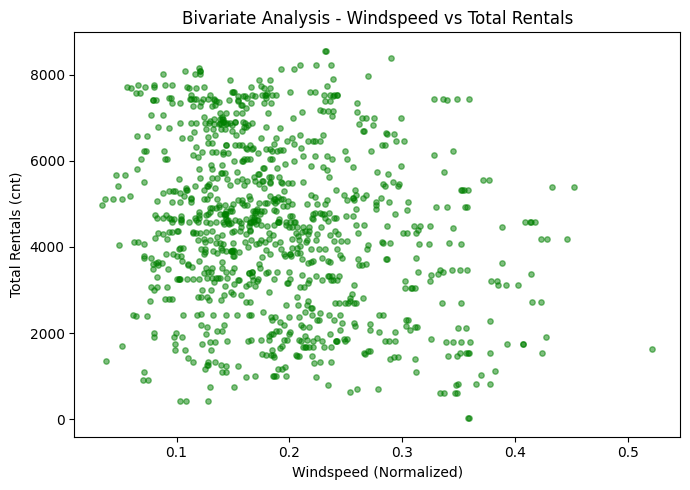

In [12]:
# Sample for faster plotting
df_plot = df.sample(n=min(1000, len(df)), random_state=42)
plt.figure(figsize=(7, 5))
plt.scatter(df_plot['windspeed'], df_plot['cnt'], alpha=0.5, color='green', s=15)
plt.title('Bivariate Analysis - Windspeed vs Total Rentals')
plt.xlabel('Windspeed (Normalized)')
plt.ylabel('Total Rentals (cnt)')
plt.tight_layout()
plt.show()

## **B) Numerical vs Categorical**

### **Boxplot**

<Figure size 700x500 with 0 Axes>

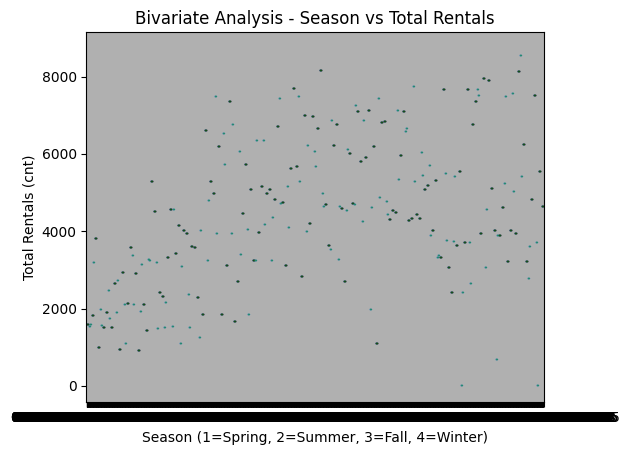

In [13]:
# Sample for faster plotting
df_plot = df.sample(n=min(2000, len(df)), random_state=42)
plt.figure(figsize=(7, 5))
df_plot.boxplot(column='cnt', by='season')
plt.title('Bivariate Analysis - Season vs Total Rentals')
plt.suptitle('')
plt.xlabel('Season (1=Spring, 2=Summer, 3=Fall, 4=Winter)')
plt.ylabel('Total Rentals (cnt)')
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

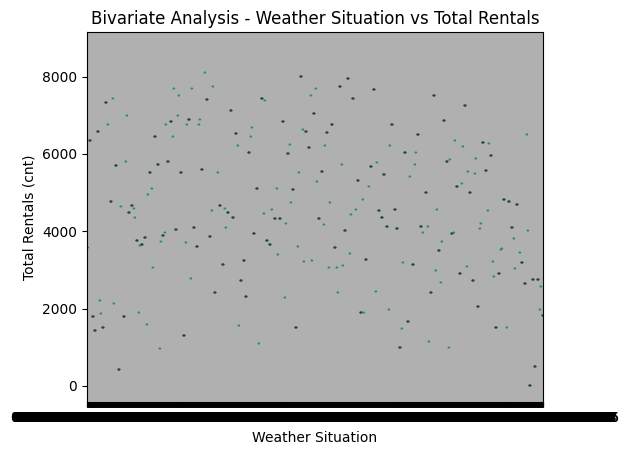

In [14]:
# Sample for faster plotting
df_plot = df.sample(n=min(2000, len(df)), random_state=42)
plt.figure(figsize=(7, 5))
df_plot.boxplot(column='cnt', by='weathersit')
plt.title('Bivariate Analysis - Weather Situation vs Total Rentals')
plt.suptitle('')
plt.xlabel('Weather Situation')
plt.ylabel('Total Rentals (cnt)')
plt.tight_layout()
plt.show()

# **MULTIVARIATE ANALYSIS (More than 2 Variables)**

## **A) Correlation Heatmap (Numerical Only)**

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46290 entries, 0 to 46289
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     46290 non-null  float64
 1   dteday      46290 non-null  object 
 2   season      46290 non-null  float64
 3   yr          46290 non-null  float64
 4   mnth        46290 non-null  float64
 5   holiday     46290 non-null  float64
 6   weekday     46290 non-null  float64
 7   workingday  46290 non-null  float64
 8   weathersit  46290 non-null  float64
 9   temp        46290 non-null  float64
 10  atemp       46290 non-null  float64
 11  hum         46290 non-null  float64
 12  windspeed   46290 non-null  float64
 13  casual      46290 non-null  float64
 14  registered  46290 non-null  float64
 15  cnt         46290 non-null  float64
dtypes: float64(15), object(1)
memory usage: 5.7+ MB


In [16]:
num_cols = ["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]

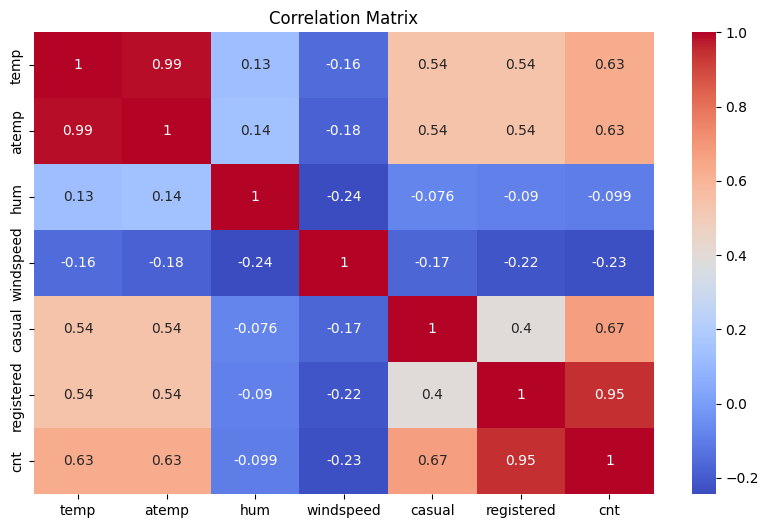

In [17]:
plt.figure(figsize=(10, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## **B) Pairplot**

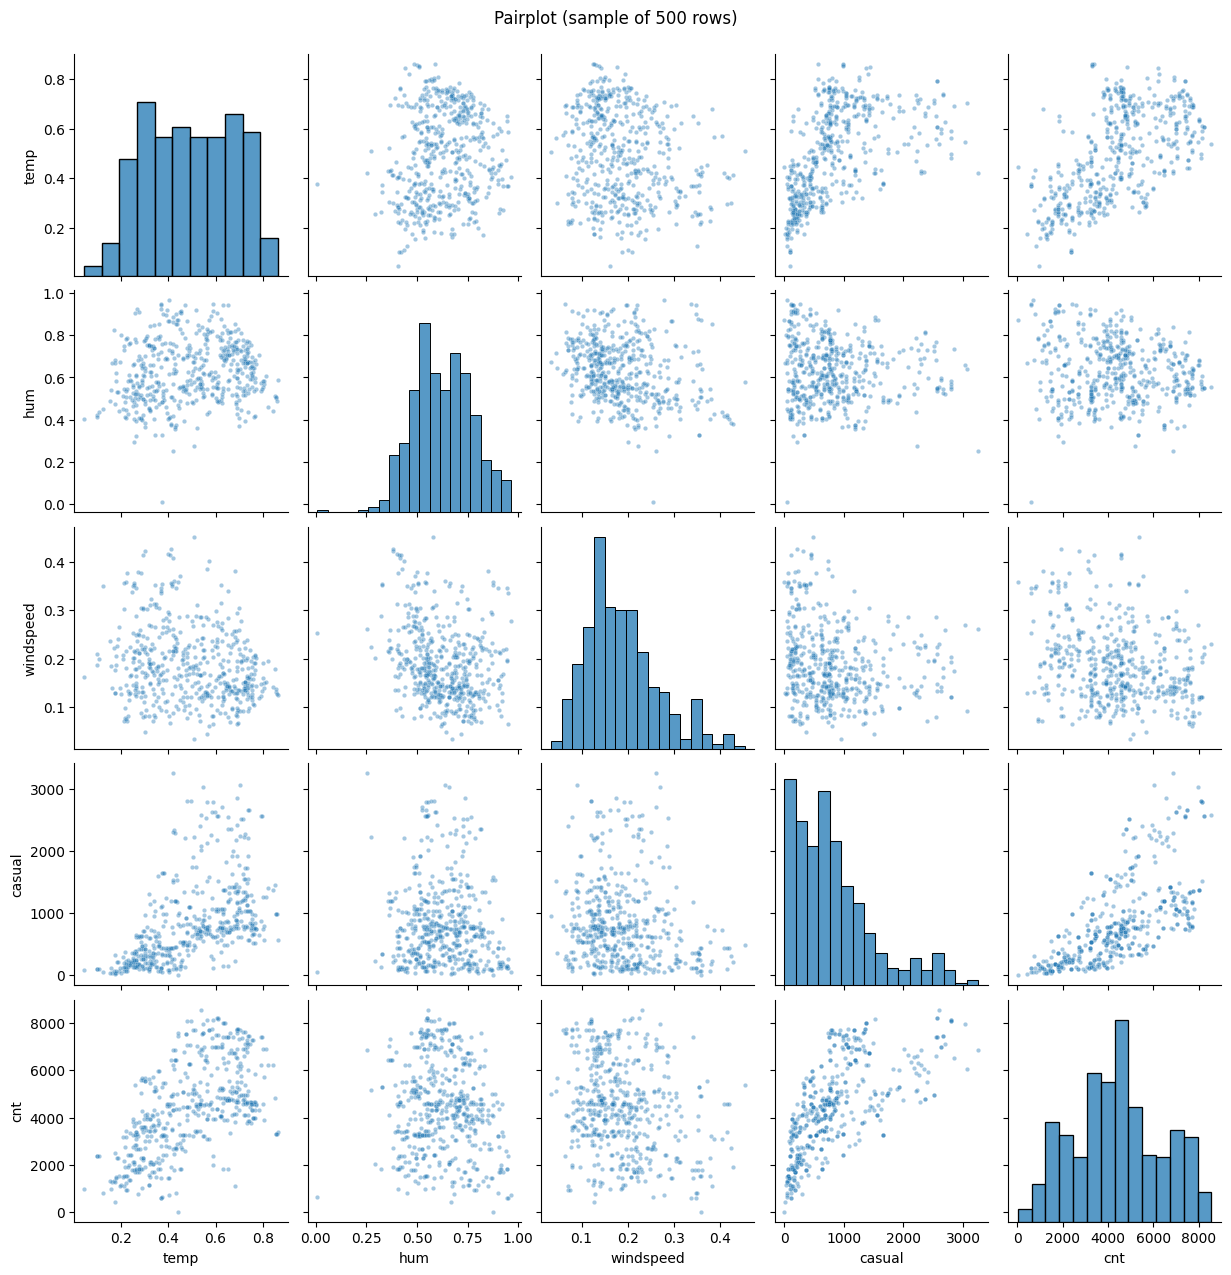

In [18]:
# Sample heavily for pairplot (very slow on large datasets)
selected_cols = ['temp', 'hum', 'windspeed', 'casual', 'cnt']
df_sample = df[selected_cols].sample(n=min(500, len(df)), random_state=42)
sns.pairplot(df_sample, plot_kws={'alpha': 0.4, 's': 10})
plt.suptitle('Pairplot (sample of 500 rows)', y=1.02)
plt.show()

# **Step 4 : Preprocessing**

In [19]:
# Drop irrelevant identifier and date columns
df = df.drop(columns=['dteday', 'instant'])
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,0.995843,0.016018,0.982600,-0.003477,5.992394,-0.001417,2.009839,0.350509,0.367939,0.787116,0.168656,330.998105,653.993691,985.007777
1,0.992476,0.000674,1.004417,0.002312,-0.002698,0.014306,1.988153,0.352450,0.364911,0.696719,0.259395,131.005296,669.996919,801.009116
2,1.012450,0.005877,0.981187,-0.015208,0.993581,0.991965,0.988943,0.179866,0.179076,0.442457,0.235277,119.995937,1229.016646,1349.003713
3,1.005005,-0.002214,1.032288,-0.002648,1.992651,0.998199,1.006277,0.194044,0.206866,0.614092,0.177329,108.020172,1453.995958,1562.008678
4,0.998953,0.017170,1.004892,-0.002176,3.003945,0.983012,0.992739,0.237016,0.208624,0.423478,0.184433,81.996052,1517.999923,1599.975184


In [20]:
# Check for missing values
df.isnull().sum()

season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [21]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [22]:
# Drop duplicates if any
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [23]:
# NOTE: Outlier treatment on 'casual' is kept here for EDA awareness,
# but 'casual' and 'registered' will be dropped before modelling (data leakage fix).
Q1 = df['casual'].quantile(0.25)
Q3 = df['casual'].quantile(0.75)
IQR = Q3 - Q1
print('IQR:', IQR)
print('Median:', df['casual'].median())
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print('Lower bound:', lower)
print('Upper bound:', upper)
df['casual'] = np.where(df['casual'] > upper, upper, df['casual'])

IQR: 780.0169925197375
Median: 712.9916229688276
Lower bound: -855.0255578744626
Upper bound: 2265.042412204488


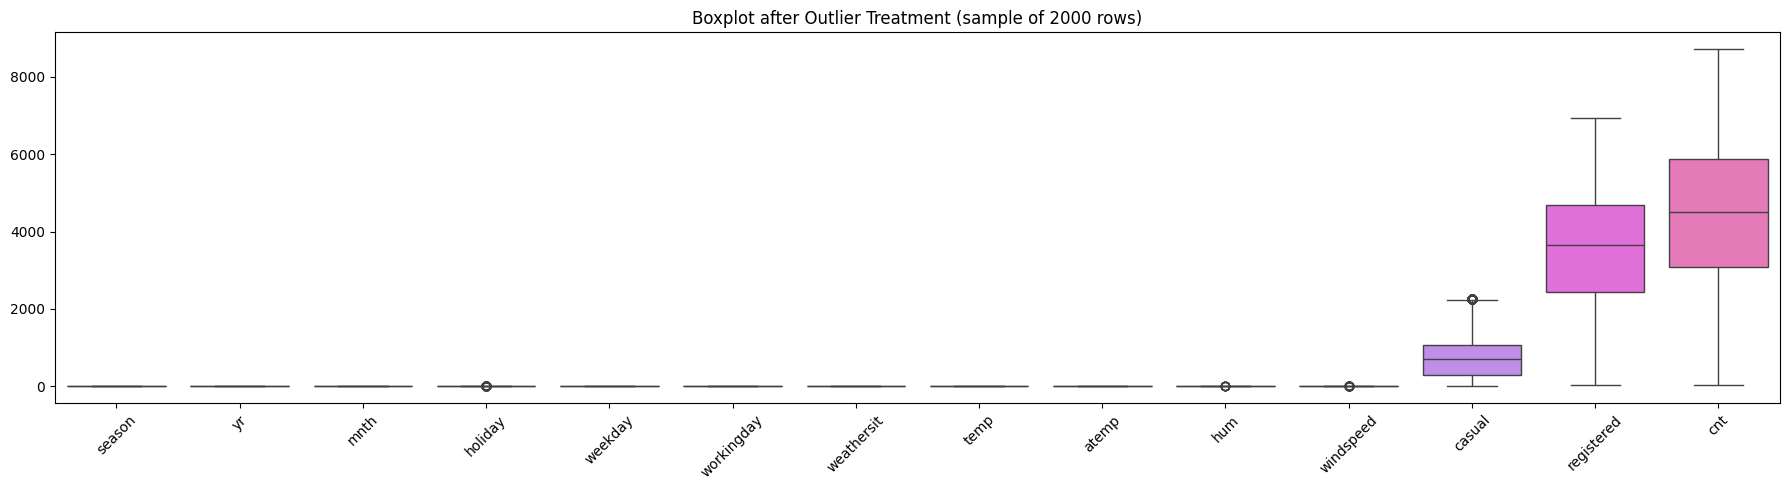

In [24]:
# Sample for faster boxplot
df_plot = df.sample(n=min(2000, len(df)), random_state=42)
plt.figure(figsize=(18, 5))
sns.boxplot(data=df_plot)
plt.xticks(rotation=45)
plt.title('Boxplot after Outlier Treatment (sample of 2000 rows)')
plt.tight_layout()
plt.show()

In [25]:
# Drop low-importance features (mnth and hum based on feature selection)
df = df.drop(columns=['mnth', 'hum'])
df.shape

(46290, 12)

In [26]:
# Define Target variable
y = df['cnt']
print(y.shape)

(46290,)


In [27]:
# Define Predictors (Input Variables)
# FIX: Drop 'casual' and 'registered' — they directly sum to 'cnt' (data leakage)
X = df.drop(columns=['cnt', 'casual', 'registered'])
X.shape

(46290, 9)

In [28]:
X.columns

Index(['season', 'yr', 'holiday', 'weekday', 'workingday', 'weathersit',
       'temp', 'atemp', 'windspeed'],
      dtype='object')

In [29]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46290 entries, 0 to 46289
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      46290 non-null  float64
 1   yr          46290 non-null  float64
 2   holiday     46290 non-null  float64
 3   weekday     46290 non-null  float64
 4   workingday  46290 non-null  float64
 5   weathersit  46290 non-null  float64
 6   temp        46290 non-null  float64
 7   atemp       46290 non-null  float64
 8   windspeed   46290 non-null  float64
dtypes: float64(9)
memory usage: 3.2 MB


# Encoding and Scaling

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [31]:
# Apply StandardScaler to all numerical columns
n_features = X.shape[1]
ts = ColumnTransformer(transformers=[
    ('t1', StandardScaler(), list(range(n_features)))
])

In [32]:
# REMOVED: Do NOT fit-transform on full X before train/test split.
# Fitting the scaler on all data (including test) causes data leakage.
# Scaling is done correctly AFTER the split in Step 6 (cells below).

# **Step 5 : Feature Selection**

In [33]:
from sklearn.feature_selection import mutual_info_regression
# Use raw X (unscaled) for mutual info — MI is scale-invariant
mi = mutual_info_regression(X, y)
mi = pd.Series(mi)
mi.index = X.columns
mi.sort_values(ascending=False)

temp          2.084218
atemp         1.957943
weekday       1.823908
season        1.228497
windspeed     1.080094
weathersit    0.584447
yr            0.580752
workingday    0.455180
holiday       0.086905
dtype: float64

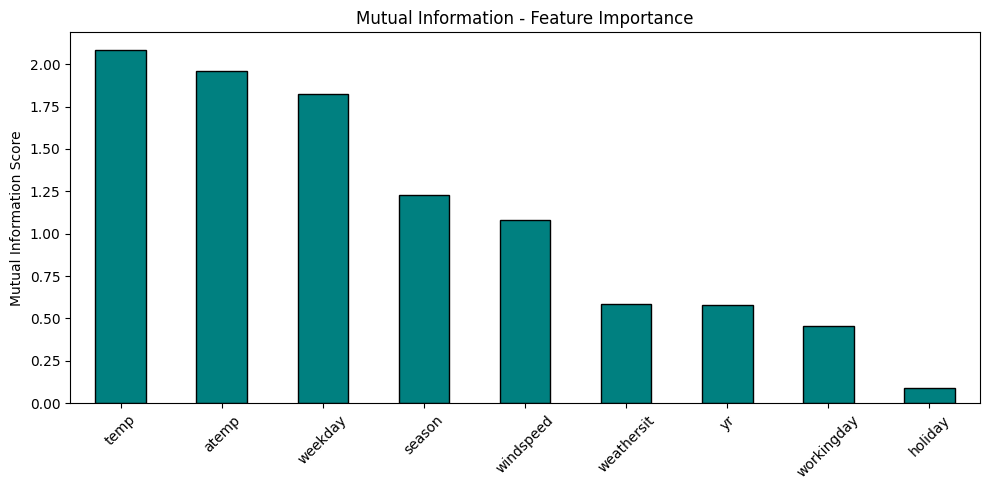

In [34]:
# Visualize feature importance
plt.figure(figsize=(10, 5))
mi.sort_values(ascending=False).plot(kind='bar', color='teal', edgecolor='black')
plt.title('Mutual Information - Feature Importance')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Step 6 : Split the Data (Train Test Split)**

In [35]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('X_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

X_train shape: (37032, 9)
y_train shape: (37032,)
X_test shape: (9258, 9)
y_test shape: (9258,)


In [36]:
X_train_trans = ts.fit_transform(x_train)
X_train_trans = pd.DataFrame(X_train_trans, columns=x_train.columns)
X_train_trans.head()

,season,yr,holiday,weekday,workingday,weathersit,temp,atemp,windspeed
0,-1.339130,-0.994450,-0.145466,-1.489959,-1.487790,-0.742081,-0.855956,-0.884203,0.341780
1,1.352167,0.986147,-0.226506,0.507836,0.696760,-0.734192,-1.290802,-1.256122,-0.119330
2,0.459516,-1.019438,-0.117388,0.504309,0.664848,1.107482,0.657842,0.579235,-0.718210
3,1.365099,1.025092,-0.177035,-1.002913,0.646911,-0.709423,-0.070292,0.135307,-1.405232
4,1.365298,-0.985306,-0.115569,-1.503212,-1.450016,-0.719994,-0.215260,-0.221332,0.185586


In [37]:
X_test_trans = ts.transform(x_test)
X_test_trans = pd.DataFrame(X_test_trans, columns=x_test.columns)
X_test_trans.head()

,season,yr,holiday,weekday,workingday,weathersit,temp,atemp,windspeed
0,-1.334857,-0.985640,-0.153142,-0.501319,0.664805,1.104606,-1.422013,-1.567528,-0.824837
1,-1.332657,-1.031786,-0.224766,-1.486746,-1.464530,-0.732893,-0.573668,-0.472918,1.185887
2,-0.424517,-0.990441,-0.111128,-1.491160,-1.454973,1.089128,-0.317608,-0.357933,-0.427867
3,-0.441624,-1.018701,-0.100163,0.497634,0.670454,1.135052,1.672028,1.795891,-0.529736
4,-0.445740,-0.986999,-0.116871,-0.992548,0.677943,1.101759,0.704527,0.739037,-0.344383


# **Step 7 : Hyperparameter Tuning**

In [38]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

knr = KNeighborsRegressor()
random_search = RandomizedSearchCV(
    knr,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='r2',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

knn_cv = random_search.fit(X_train_trans, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [39]:
best_params = knn_cv.best_params_
print(f'Best parameters: {best_params}')
print(f'Best CV R2 Score: {knn_cv.best_score_:.4f}')

Best parameters: {'weights': 'distance', 'p': 2, 'n_neighbors': 7}
Best CV R2 Score: 0.9951


# **Step 8 : Model Building (Applying Regression Models)**

## **KNN Regression**

In [40]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

knr = KNeighborsRegressor(**best_params)
knr.fit(X_train_trans, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [41]:
y_pred = knr.predict(X_test_trans)
y_train_pred = knr.predict(X_train_trans)

## **Linear Regression**

In [42]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_trans, y_train)

y_pred_lr = lr.predict(X_test_trans)
y_train_pred_lr = lr.predict(X_train_trans)

print('Train R2 for Linear Regression:', r2_score(y_train, y_train_pred_lr))
print('Test  R2 for Linear Regression:', r2_score(y_test, y_pred_lr))

Train R2 for Linear Regression: 0.7936291342151498
Test  R2 for Linear Regression: 0.8004505636508326


## **Decision Tree Regression**

In [43]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV

dt_params = {
    'max_depth': list(range(2, 12)),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeRegressor(random_state=42)
dt_cv = RandomizedSearchCV(dt, dt_params, scoring='r2', cv=5, n_iter=10, verbose=1, n_jobs=-1, random_state=42)
dt_cv.fit(X_train_trans, y_train)
print('Best DT params:', dt_cv.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best DT params: {'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 9}


In [44]:
dt_best = dt_cv.best_estimator_
y_pred_dt = dt_best.predict(X_test_trans)
y_train_pred_dt = dt_best.predict(X_train_trans)

print('Train R2 for Decision Tree:', r2_score(y_train, y_train_pred_dt))
print('Test  R2 for Decision Tree:', r2_score(y_test, y_pred_dt))

Train R2 for Decision Tree: 0.9551699617653246
Test  R2 for Decision Tree: 0.9515274552739575


## **Support Vector Regression (SVR)**

In [45]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV

svr_params = {
    'C': [0.1, 1],
    'epsilon': [0.1],
    'kernel': ['linear']
}

svr = SVR()

svr_cv = RandomizedSearchCV(
    svr,
    svr_params,
    scoring='r2',
    cv=3,
    n_iter=3,
    n_jobs=-1,
    random_state=42
)

# Use smaller data
X_small = X_train_trans[:10000]
y_small = y_train[:10000]

svr_cv.fit(X_small, y_small)

print("Best params:", svr_cv.best_params_)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 2 is smaller than n_iter=3. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params: {'kernel': 'linear', 'epsilon': 0.1, 'C': 1}


In [46]:
svr_best = svr_cv.best_estimator_
y_pred_svr       = svr_best.predict(X_test_trans)
y_train_pred_svr = svr_best.predict(X_train_trans)

print('Train R2 for SVR:', round(r2_score(y_train, y_train_pred_svr), 4))
print('Test  R2 for SVR:', round(r2_score(y_test,  y_pred_svr),       4))

Train R2 for SVR: 0.7873
Test  R2 for SVR: 0.7937


## **Random Forest Regression**

In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_cv = RandomizedSearchCV(
    rf,
    rf_params,
    scoring='r2',
    cv=3,
    n_iter=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rf_cv.fit(X_train_trans, y_train)

print("Best RF params:", rf_cv.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best RF params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}


In [48]:
rf_best = rf_cv.best_estimator_
y_pred_rf       = rf_best.predict(X_test_trans)
y_train_pred_rf = rf_best.predict(X_train_trans)

print('Train R2 for Random Forest:', round(r2_score(y_train, y_train_pred_rf), 4))
print('Test  R2 for Random Forest:', round(r2_score(y_test,  y_pred_rf),       4))

Train R2 for Random Forest: 0.9769
Test  R2 for Random Forest: 0.9734


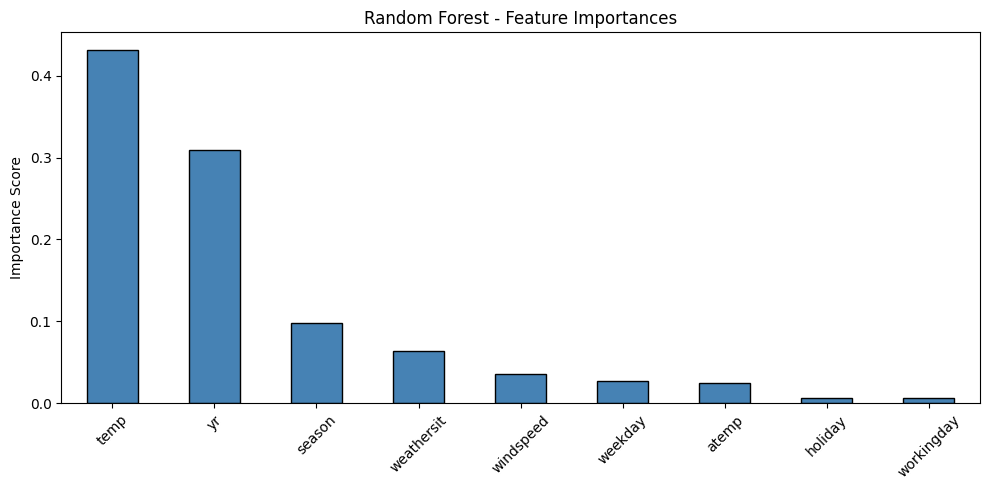

In [49]:
# Feature Importance - Random Forest
feat_imp = pd.Series(rf_best.feature_importances_, index=x_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Random Forest - Feature Importances')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Gradient Boosting Regression**

In [50]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

gb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingRegressor(random_state=42)

gb_cv = RandomizedSearchCV(
    gb,
    gb_params,
    scoring='r2',
    cv=3,
    n_iter=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

gb_cv.fit(X_train_trans, y_train)

print("Best GB params:", gb_cv.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best GB params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}


In [51]:
gb_best = gb_cv.best_estimator_
y_pred_gb       = gb_best.predict(X_test_trans)
y_train_pred_gb = gb_best.predict(X_train_trans)

print('Train R2 for Gradient Boosting:', round(r2_score(y_train, y_train_pred_gb), 4))
print('Test  R2 for Gradient Boosting:', round(r2_score(y_test,  y_pred_gb),       4))

Train R2 for Gradient Boosting: 0.9611
Test  R2 for Gradient Boosting: 0.9579


# **Step 9 : Evaluation Metrics**

In [52]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

all_results = {
    'KNN':               (y_train_pred,    y_pred),
    'Linear Regression': (y_train_pred_lr, y_pred_lr),
    'Decision Tree':     (y_train_pred_dt, y_pred_dt),
    'SVR':               (y_train_pred_svr, y_pred_svr),
    'Random Forest':     (y_train_pred_rf, y_pred_rf),
    'Gradient Boosting': (y_train_pred_gb, y_pred_gb),
}

for name, (y_tr, y_te) in all_results.items():
    print('=' * 50)
    print(name)
    print('=' * 50)
    print('Train R2  :', round(r2_score(y_train, y_tr), 4))
    print('Test  R2  :', round(r2_score(y_test,  y_te), 4))
    print('MAE       :', round(mean_absolute_error(y_test, y_te), 2))
    print('RMSE      :', round(np.sqrt(mean_squared_error(y_test, y_te)), 2))
    print()

KNN
Train R2  : 1.0
Test  R2  : 0.995
MAE       : 33.36
RMSE      : 137.47

Linear Regression
Train R2  : 0.7936
Test  R2  : 0.8005
MAE       : 646.74
RMSE      : 867.74

Decision Tree
Train R2  : 0.9552
Test  R2  : 0.9515
MAE       : 274.39
RMSE      : 427.68

SVR
Train R2  : 0.7873
Test  R2  : 0.7937
MAE       : 648.13
RMSE      : 882.34

Random Forest
Train R2  : 0.9769
Test  R2  : 0.9734
MAE       : 206.14
RMSE      : 316.76

Gradient Boosting
Train R2  : 0.9611
Test  R2  : 0.9579
MAE       : 276.04
RMSE      : 398.39



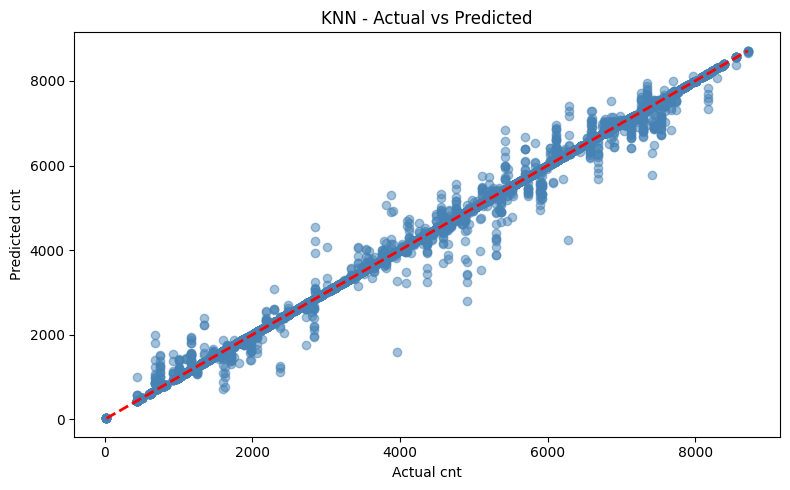

In [53]:
# Visualize Actual vs Predicted - KNN
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('KNN - Actual vs Predicted')
plt.xlabel('Actual cnt')
plt.ylabel('Predicted cnt')
plt.tight_layout()
plt.show()

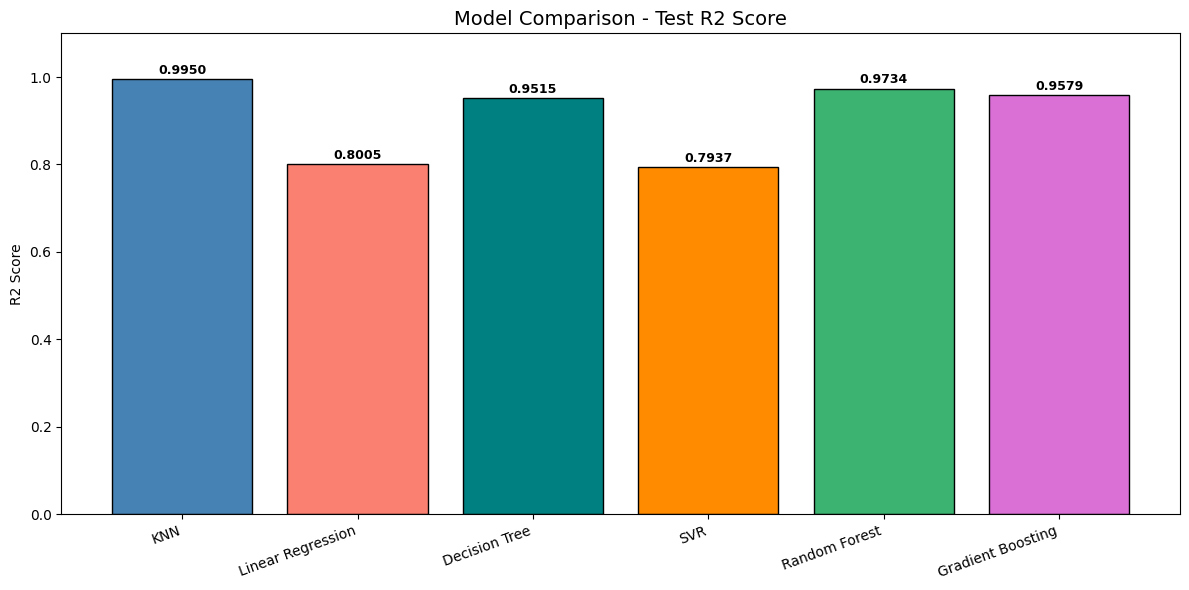

In [54]:
# Model Comparison Bar Chart
models_cmp = ['KNN', 'Linear Regression', 'Decision Tree', 'SVR', 'Random Forest', 'Gradient Boosting']
r2_scores_cmp = [
    r2_score(y_test, y_pred),
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_svr),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_gb),
]

colors = ['steelblue', 'salmon', 'teal', 'darkorange', 'mediumseagreen', 'orchid']
plt.figure(figsize=(12, 6))
bars = plt.bar(models_cmp, r2_scores_cmp, color=colors, edgecolor='black')
for bar, score in zip(bars, r2_scores_cmp):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
plt.title('Model Comparison - Test R2 Score', fontsize=14)
plt.ylabel('R2 Score')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

In [55]:
import pickle

# Automatically select best model based on Test R2
model_map = {
    'KNN':               knr,
    'Linear Regression': lr,
    'Decision Tree':     dt_best,
    'SVR':               svr_best,
    'Random Forest':     rf_best,
    'Gradient Boosting': gb_best,
}

best_model_name = max(model_map.keys(),
                      key=lambda m: r2_score(y_test, model_map[m].predict(X_test_trans)))
best_model = model_map[best_model_name]
print(f'Best model: {best_model_name}')

model_bundle = {
    'transformer':  ts,
    'model':        best_model,
    'model_name':   best_model_name,
    'feature_cols': list(x_train.columns)
}

with open('bikemodel.pkl', 'wb') as file:
    pickle.dump(model_bundle, file)

print('Model saved successfully as bikemodel.pkl')

Best model: KNN
Model saved successfully as bikemodel.pkl
